# PKTD3-TD: Training on Google Colab (T4 GPU)

This notebook executes the full training procedure (Algorithm 1) of **PKTD3-TD** using GPU acceleration on Google Colab.

Reference Paper:  
> *M. Li et al., "3-D Trajectory Design Based on Deep Reinforcement Learning for UAV-Assisted Communication Networks," IEEE Transactions on Network Science and Engineering, vol. 13, no. 1, pp. 248–261, 2026.*

---
### Prerequisites & Setup Instructions
1. **Enable Hardware Acceleration:**  
   In Google Colab, go to **Runtime** > **Change runtime type** > Select **T4 GPU** > Click **Save**.
2. **Store GitHub Personal Access Token (PAT):**  
   In the left sidebar, click on the **Secrets (key icon)**:  
   - Click **Add new secret**  
   - Name: `GITHUB_PAT_TOKEN`  
   - Value: `<your-github-personal-access-token>` (with repo write permissions)  
   - Toggle **Notebook access** to **ON**.
3. **Google Drive Backup:**  
   Google Drive is mounted to save checkpoints continuously in real time. If Colab disconnects or times out, your checkpoints remain safe in Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Step 1: Mount Google Drive for persistent checkpoint backup
import os
from google.colab import drive

drive.mount('/content/drive')
drive_backup_dir = '/content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run2'
os.makedirs(drive_backup_dir, exist_ok=True)
print(f"Persistent backup directory ready: {drive_backup_dir}")

Mounted at /content/drive
Persistent backup directory ready: /content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run1


In [2]:
# Step 2: Clone repository using GITHUB_PAT_TOKEN secret
import os
from google.colab import userdata

github_token = userdata.get('GITHUB_PAT_TOKEN')
repo_owner = "Krishna200608"
repo_name = "uav_trajectory_rl"
repo_url = f"https://{github_token}@github.com/{repo_owner}/{repo_name}.git"

work_dir = f"/content/{repo_name}"
if not os.path.exists(work_dir):
    !git clone {repo_url} {work_dir}
    %cd {work_dir}
else:
    %cd {work_dir}
    !git pull

!git status

Cloning into '/content/uav_trajectory_rl'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 118 (delta 55), reused 101 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 66.35 KiB | 11.06 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/uav_trajectory_rl
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [3]:
# Step 3: Install dependencies and verify GPU acceleration
!pip install -e ".[dev]"

import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU is not enabled! Switch runtime to T4 GPU in Runtime > Change runtime type.")

# Run unit tests to confirm environment integrity
!pytest tests/ -q

Obtaining file:///content/uav_trajectory_rl
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for uav-trajectory-rl (pyproject.toml) ... done
  Created wheel for uav-trajectory-rl: filename=uav_trajectory_rl-0.1.0-0.editable-py3-none-any.whl size=1467 sha256=49b42cf42512c0c17f00915b9b58ed2b0538159fcc1bc3c73f4bd17ed2f85284
  Stored in directory: /tmp/pip-ephem-wheel-cache-ni2jj9zy/wheels/d8/cb/ff/2488f5dfe83c80279a67b632b0d14c03861276b1bebef75408
Successfully built uav-trajectory-rl
PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device: Tesla T4
..................................                                       [100%]
34 passed in 14.34s


In [ ]:
# Step 4: Execute PKTD3-TD Training with Live Visual Progress Bar & ETA
# Checkpoints are saved directly to Google Drive so no progress is lost upon disconnection
import os, sys, shutil

# Ensure local package source is resolvable in Colab kernel
for p in ["/content/uav_trajectory_rl/src", "/content/uav_trajectory_rl", "src", "."]:
    abs_p = os.path.abspath(p)
    if os.path.exists(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)

from scripts.train import main

local_checkpoint_dir = "/content/uav_trajectory_rl/checkpoints/run2"
os.makedirs(local_checkpoint_dir, exist_ok=True)

# Running main() directly renders Colab's native interactive HTML progress bar widget
# Complete with percentage, colored bar, elapsed time, ETA, speed (ep/s), and live reward stats
episode_rewards = main(
    num_episodes=6000,
    k_users=10,
    batch_size=128,
    seed=0,
    checkpoint_dir=drive_backup_dir,
    checkpoint_every=500,
    log_every=20,
    use_progress_bar=True,
)

# Sync all checkpoints and reward history from Drive to local repository folder
print("\nCopying saved checkpoints into local repository folder...")
shutil.copytree(drive_backup_dir, local_checkpoint_dir, dirs_exist_ok=True)
!ls -lh "{local_checkpoint_dir}"


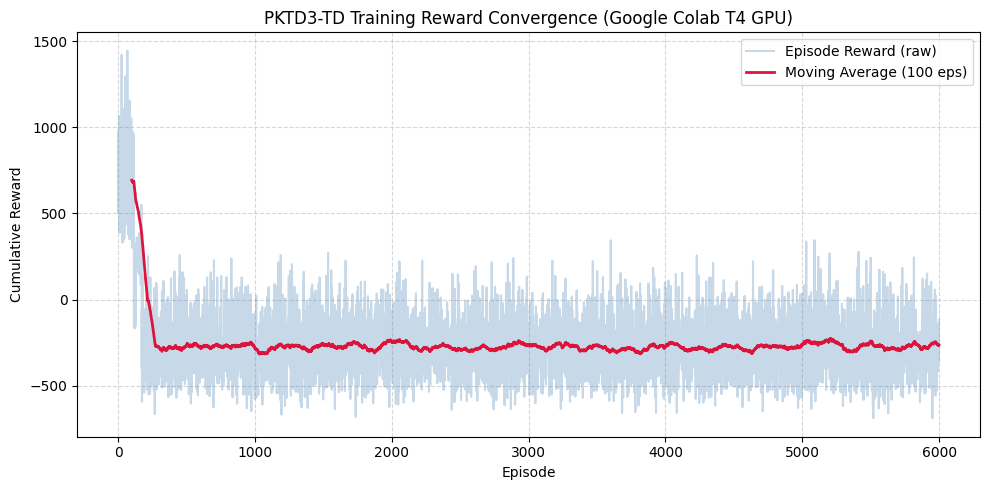

Reward curve saved to /content/uav_trajectory_rl/checkpoints/run1/training_reward_curve.png


In [5]:
# Step 5: Plot and visualize reward convergence
import os
import numpy as np
import matplotlib.pyplot as plt

rewards_file = os.path.join(local_checkpoint_dir, "episode_rewards.npy")
if os.path.exists(rewards_file):
    rewards = np.load(rewards_file)
    window = 100
    moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, color="steelblue", label="Episode Reward (raw)")
    plt.plot(range(window - 1, len(rewards)), moving_avg, color="crimson", linewidth=2, label=f"Moving Average ({window} eps)")
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.title("PKTD3-TD Training Reward Convergence (Google Colab T4 GPU)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plot_path = os.path.join(local_checkpoint_dir, "training_reward_curve.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Reward curve saved to {plot_path}")
else:
    print(f"Rewards file not found at {rewards_file}")

In [6]:
# Step 6: Commit and push all checkpoints and results to GitHub
!git config --global user.name "Krishna200608"
!git config --global user.email "krishnasikheriya001@gmail.com"

# Force-add checkpoints/run1 (overriding .gitignore for saved model artifacts)
!git add -f checkpoints/run2
!git status

!git commit -m "Add PKTD3-TD trained model checkpoints and reward history from Colab T4 run"
!git push origin main
print("\nSuccessfully pushed checkpoints and reward logs to GitHub!")

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/run1/episode_rewards.npy
	new file:   checkpoints/run1/td3_agent_ep1000.pt
	new file:   checkpoints/run1/td3_agent_ep1500.pt
	new file:   checkpoints/run1/td3_agent_ep2000.pt
	new file:   checkpoints/run1/td3_agent_ep2500.pt
	new file:   checkpoints/run1/td3_agent_ep3000.pt
	new file:   checkpoints/run1/td3_agent_ep3500.pt
	new file:   checkpoints/run1/td3_agent_ep4000.pt
	new file:   checkpoints/run1/td3_agent_ep4500.pt
	new file:   checkpoints/run1/td3_agent_ep500.pt
	new file:   checkpoints/run1/td3_agent_ep5000.pt
	new file:   checkpoints/run1/td3_agent_ep5500.pt
	new file:   checkpoints/run1/td3_agent_ep6000.pt
	new file:   checkpoints/run1/td3_agent_final.pt
	new file:   checkpoints/run1/training_reward_curve.png

[main eaa6f33] Add PKTD3-TD trained model checkpoints and reward history from Colab T4 run
 15 files chang